In [17]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch

In [18]:
def target_function(x):
    return x* np.sin(x)

In [19]:
X_train = np.linspace(-10,10, 500).reshape(-1, 1)
y_train = target_function(X_train)

In [20]:
X = torch.tensor(X_train, dtype = torch.float32)
y = torch.tensor(y_train, dtype = torch.float32)

In [21]:
model = nn.Sequential(
    nn.Linear(1, 50), 
    nn.ReLU(),
    nn.Linear(50, 1)
)

In [22]:
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


In [29]:
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = loss_func(y_pred, y)
    loss.backward()
    optimizer.step()

In [30]:
y_pred = model(X).detach().numpy()

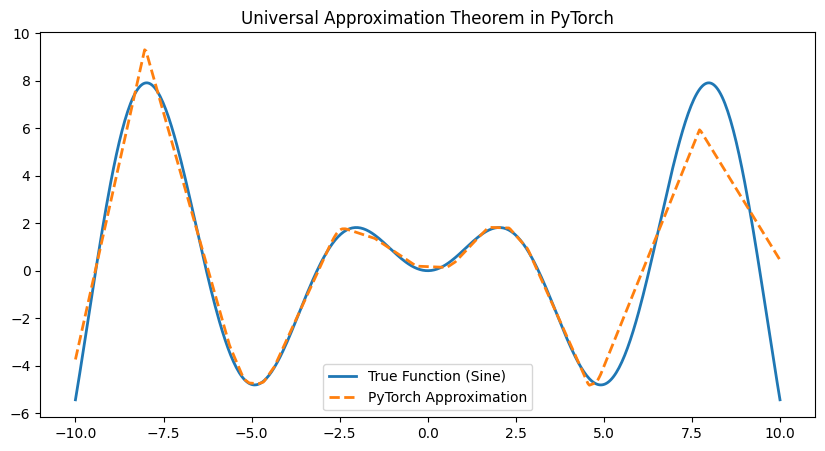

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(X_train, y_train, label='True Function (Sine)', linewidth=2)
plt.plot(X_train, y_pred, label='PyTorch Approximation', linestyle='dashed', linewidth=2)
plt.title('Universal Approximation Theorem in PyTorch')
plt.legend()
plt.show()